In [12]:
# ============================================
# 1) PARÂMETROS
# ============================================
import numpy as np
import matplotlib.pyplot as plt

random_seed = 42

# Domínio de busca
x_min, x_max = -1*np.pi, 1*np.pi
y_min, y_max = -1*np.pi, 1*np.pi

# Resolução dos gráficos
grid_n = 300

# Outros parâmetros
passo      = 0.70     # tamanho do passo para a vizinhanca
iter_max   = 600      # número máximo de iterações
T0         = 6.0      # temperatura inicial (define quão "exploratório" o início será)
alpha      = 0.99     # taxa de resfriamento (T <- T * alpha a cada iteração)
T_min      = 1e-4     # temperatura mínima; quando T < T_min, a busca é encerrada

# Ponto inicial (se None, será aleatório)
inicio_x = None
inicio_y = None

rng = np.random.default_rng(random_seed)

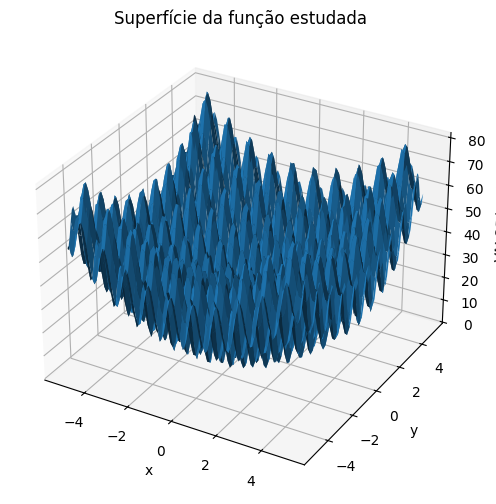

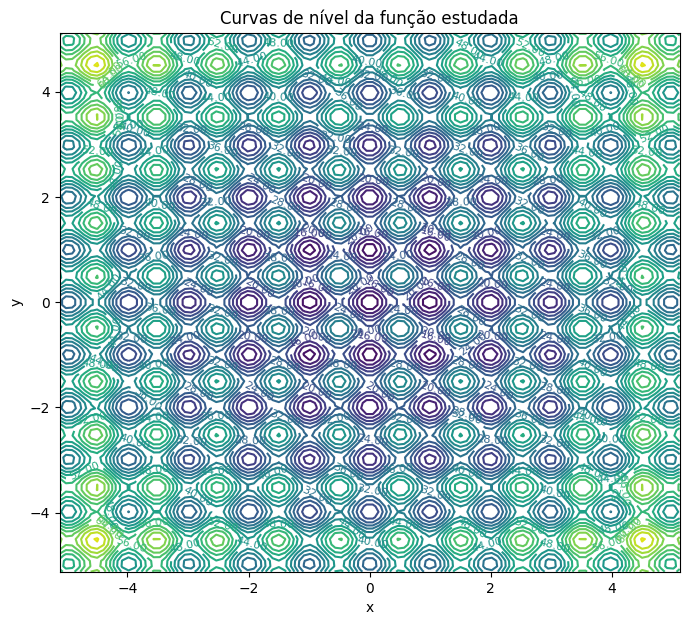

In [13]:
import numpy as np
import matplotlib.pyplot as plt
def rastrigin(x, y):
    return 20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y))

x = np.linspace(-5.12, 5.12, 100)
y = np.linspace(-5.12, 5.12, 100)
X, Y = np.meshgrid(x, y)
Z = rastrigin(X, Y)

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)
ax.set_title('Superfície da função estudada')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('VALOR(x,y)')
plt.show()

# Curvas de nível
plt.figure(figsize=(8,7))
cs = plt.contour(X, Y, Z, levels=25)
plt.clabel(cs, inline=1, fontsize=8, fmt="%.2f")
plt.title('Curvas de nível da função estudada')
plt.xlabel('x'); plt.ylabel('y')
plt.show()


In [14]:
def CLAMP(v, lo, hi):
    return max(lo, min(hi, v))

def SUCESSORES(corrente, passo):
    """Gera a 8-vizinhança (Vizinhança de Moore)."""
    x, y = corrente
    succ = []
    for dx in [-passo, 0, passo]:
        for dy in [-passo, 0, passo]:
            if dx == 0 and dy == 0:
                continue
            xn = CLAMP(x + dx, x_min, x_max)
            yn = CLAMP(y + dy, y_min, y_max)
            succ.append((xn, yn))
    return succ

In [15]:
# ============================================
# 4) TÊMPERA SIMULADA — SIMULATED ANNEALING
# ============================================
def PROXIMO_ALEATORIO(atual, passo):
    """Gera um vizinho aleatório dentro do passo definido."""
    x, y = atual
    xn = CLAMP(x + np.random.uniform(-passo, passo), x_min, x_max)
    yn = CLAMP(y + np.random.uniform(-passo, passo), y_min, y_max)
    return (xn, yn)

def TEMPERA_SIMULADA(ESTADO_INICIAL,
                     passo=passo, T0=T0, alpha=alpha,
                     T_min=T_min, iter_max=iter_max):
    atual = ESTADO_INICIAL
    valor_atual = rastrigin(*atual)

    T = T0
    for _ in range(iter_max):
        if T <= T_min:
            break
        proximo = PROXIMO_ALEATORIO(atual, passo)
        deltaE = rastrigin(*proximo) - valor_atual
        # regra de aceitação
        if deltaE > 0 or np.exp(deltaE / T) > np.random.rand():
            atual = proximo
            valor_atual = rastrigin(*atual)
        T *= alpha
    return atual

# Exemplo rápido
xi = rng.uniform(x_min, x_max)
yi = rng.uniform(y_min, y_max)
valor_inicial = rastrigin(xi, yi)
final = TEMPERA_SIMULADA((xi, yi))
valor_final = rastrigin(*final)

print(f"Início: ({xi:.3f}, {yi:.3f})  →  rastrigin inicial: {valor_inicial:.4f}")
print(f"Final:  {final}  →  rastrigin final: {valor_final:.4f}  →  Ganho: {valor_final - valor_inicial:+.4f}")


Início: (1.721, -0.384)  →  rastrigin inicial: 32.3639
Final:  (1.5026066533659208, -1.510529442040748)  →  rastrigin final: 44.5163  →  Ganho: +12.1524


Início: (2.253, 1.240)  →  rastrigin inicial: 26.1899
Final:  (2.5096378034314406, 0.5099997698687875)  →  rastrigin final: 46.5203  →  Ganho: +20.3304


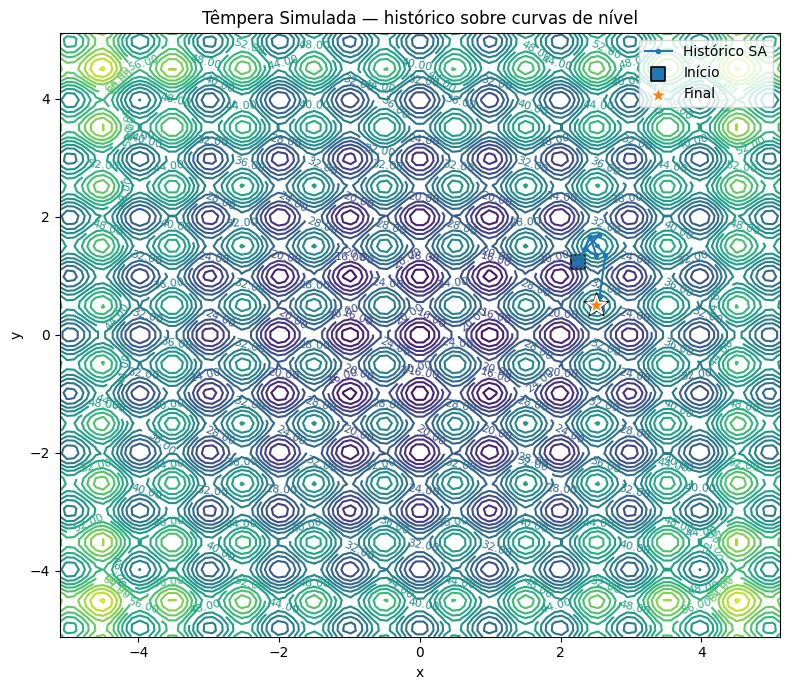

In [16]:
# ============================================
# 5) TÊMPERA SIMULADA — COM HISTÓRICO (para plot)
# ============================================
def TEMPERA_SIMULADA_HISTORICO(ESTADO_INICIAL,
                     passo=passo, T0=T0, alpha=alpha,
                     T_min=T_min, iter_max=iter_max):
    atual = ESTADO_INICIAL
    valor_atual = rastrigin(*atual)
    historico = [atual]

    T = T0
    for _ in range(iter_max):
        if T <= T_min:
            break
        proximo = PROXIMO_ALEATORIO(atual, passo)
        deltaE = rastrigin(*proximo) - valor_atual
        # regra de aceitação
        if deltaE > 0 or np.exp(deltaE / T) > np.random.rand():
            atual = proximo
            valor_atual = rastrigin(*atual)
            historico.append(atual)
        T *= alpha
    return atual, historico

# Exemplo com histórico
xi = rng.uniform(x_min, x_max)
yi = rng.uniform(y_min, y_max)
valor_inicial = rastrigin(xi, yi)
final, historico = TEMPERA_SIMULADA_HISTORICO((xi, yi))
valor_final = rastrigin(*final)

print(f"Início: ({xi:.3f}, {yi:.3f})  →  rastrigin inicial: {valor_inicial:.4f}")
print(f"Final:  {final}  →  rastrigin final: {valor_final:.4f}  →  Ganho: {valor_final - valor_inicial:+.4f}")

# Plot da Têmpera Simulada usando CURVAS DE NÍVEL (estilo HC)
plt.figure(figsize=(8,7))

# curvas de nível com rótulos (mesmo estilo do HC)
cs = plt.contour(X, Y, Z, levels=25)
plt.clabel(cs, inline=1, fontsize=8, fmt="%.2f")

# trilha do SA (azul, visível sobre linhas)
arr = np.array(historico)
plt.plot(
    arr[:,0], arr[:,1],
    marker='o', markersize=3, linewidth=1.5,
    label="Histórico SA"
)

# início (quadrado)
plt.scatter([xi], [yi],
    marker='s', s=90,
    edgecolors='black', linewidths=1.2,
    label="Início"
)

# final (estrela com halo leve para destacar sobre linhas)
xf, yf = arr[-1,0], arr[-1,1]
plt.scatter([xf], [yf],
    marker='*', s=340, c='white', edgecolors='black', linewidths=0.8, zorder=8)  # halo
plt.scatter([xf], [yf],
    marker='*', s=200, c='tab:orange', edgecolors='white', linewidths=1.4, zorder=9,
    label="Final"
)

plt.title("Têmpera Simulada — histórico sobre curvas de nível")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
